# Primena neuronskih mreža za predviđanje i optimizaciju troškova na cloud-u (Cloud cost optimization)


## 1. Opis problema

Pri pokretanju posla u cloud okruženju (npr. treniranje ML modela, obrada podataka), korisnik bira **konfiguraciju resursa** - tip virtuelne mašine (broj vCPU-a, količina RAM-a) i broj čvorova u klasteru. Ova odluka direktno određuje dve suprotstavljene veličine:

- **trošak** izvršavanja (veći/skuplji resursi -> viša cena po satu, ali kraće vreme),
- **vreme izvršavanja** (latencija) posla.

Ciljevi ovog projekta su:

1. **Predviđanje** - istrenirati neuronske mreže koje na osnovu (a) opisa posla (tip zadatka i ulaznog dataseta) i (b) konfiguracije resursa (vCPU, RAM, broj čvorova) predviđaju očekivani **trošak** i **vreme izvršavanja**.
2. **Optimizacija** - koristeći istrenirane modele kao "orakl", implementirati algoritam **lokalne (greedy) pretrage** koji za dati posao i zadato ograničenje (npr. "završi ovaj posao za manje od X sekundi") pronalazi konfiguraciju resursa koja **minimizuje trošak**, bez potrebe za brute-force isprobavanjem svih mogućih konfiguracija.

Ovakav pristup je koristan jer real-world eksperimentisanje sa cloud resursima (pokretanje istog posla na desetinama konfiguracija radi poređenja) je i vremenski i finansijski skupo - model naučen na istorijskim merenjima omogućava da se taj prostor pretraži "offline".


## 2. Podaci

### 2.1 Izvor

Koristimo javno dostupan [IBM multi-cloud-configuration dataset](https://github.com/IBM/multi-cloud-configuration-dataset), prikupljen za rad Lazuka et al., *"Search-based Methods for Multi-Cloud Configuration"*, IEEE CLOUD 2022 (arXiv:2204.09437).

Dataset sadrži merenja izvršavanja 30 kombinacija (10 Dask ML zadataka × 3 ulazna dataseta) na 88 različitih konfiguracija resursa, raspoređenih preko 3 cloud provajdera. Da bi se sprečila konkurentska analiza cena, **provajderi i njihovi konfiguracioni parametri su anonimizovani** label-encoding-om (provajder je označen kao A/B/C, a family/type/vcpu parametri celobrojnim kodovima 0/1/2 bez objašnjenja šta predstavljaju).

Za naš cilj (predviđanje na osnovu **stvarnih** vCPU/RAM specifikacija) ova anonimizacija je problem - moramo je prvo dekodirati.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 120)
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

raw = pd.read_csv("data/multi-cloud-configuration.csv", index_col=0)
print("Oblik sirovog dataseta:", raw.shape)
raw.head()


Oblik sirovog dataseta: (2507, 13)


,provider,A_family,A_vcpu,B_family,B_vcpu,C_family,C_type,C_vcpu,nodes,workload,target_cost,target_runtime,status
0,C,NaN,NaN,NaN,NaN,1.0,1.0,1.0,3,buzz-logistic_regression,0.024583,188.857647,ok
1,C,NaN,NaN,NaN,NaN,1.0,1.0,0.0,3,buzz-standard_scaler,0.000558,8.573995,ok
2,C,NaN,NaN,NaN,NaN,1.0,0.0,0.0,4,creditcard-poisson_regression,0.006502,55.943406,ok
3,B,NaN,NaN,1.0,0.0,NaN,NaN,NaN,4,santander-spectral_clustering,0.003819,14.564142,"Input contains NaN, infinity or a value too 0 ..."
4,C,NaN,NaN,NaN,NaN,1.0,2.0,0.0,3,santander-kmeans,0.012438,114.547783,ok


### 2.2 Dekodiranje anonimizacije

Anonimizacija sakriva dve stvari: identitet provajdera (A/B/C) i vrednosti njegovih konfiguracionih parametara (family/type/vcpu, kodirane kao 0/1/2). Rešavamo ih u dva koraka:

1. **Identitet provajdera** - otkriva se iz same *strukture* parametara (koliko vrednosti uzima svaki), bez ikakvog računanja cena.
2. **Koja vrednost je koja** (npr. da li je `C_family=0` zapravo `e2` ili `n1`) - utvrđeno poređenjem redosleda cena unutar dataseta sa poznatim cenovnim hijerarhijama realnih instanci. Puna metodologija i provera dokumentovani su u `data/README_mapping.md`.

In [2]:
for prov, cols in [("A", ["A_family", "A_vcpu"]),
                    ("B", ["B_family", "B_vcpu"]),
                    ("C", ["C_family", "C_type", "C_vcpu"])]:
    nunique = [raw[c].nunique() for c in cols]
    total_combos = 1
    for n in nunique:
        total_combos *= n
    print(f"Provider {prov}: {dict(zip(cols, nunique))} -> {total_combos} kombinacija")

Provider A: {'A_family': 3, 'A_vcpu': 2} -> 6 kombinacija
Provider B: {'B_family': 2, 'B_vcpu': 2} -> 4 kombinacija
Provider C: {'C_family': 2, 'C_type': 3, 'C_vcpu': 2} -> 12 kombinacija


Ova kombinatorika se poklapa samo sa jednom realnom ponudom po provajderu:

- **Provider A** (3×2=6 kombinacija): jedini poznati provajder sa tačno 3 familije instanci u 2 veličine je **AWS** (m4, r4, c4 × large, xlarge)
- **Provider B** (2×2=4 kombinacije): odgovara **Azure**-u (D_v2, D_v3 × 2, 4 vCPU)
- **Provider C** (2×3×2=12 kombinacija): odgovara **GCP**-u, jedinom koji pored familije i veličine ima i treću dimenziju - tip mašine (e2, n1 × standard/highcpu/highmem × 2, 4 vCPU)

Koja tačno vrednost (0 ili 1) odgovara kojoj konkretnoj familiji/tipu utvrđeno je poređenjem redosleda cena sa poznatim cenovnicima (npr. e2 jeftiniji od n1, highcpu < standard < highmem) - puna provera je u `data/README_mapping.md`. Pošto (kao što je objašnjeno u 2.3) dalje radimo samo sa GCP-om, evo finalnog dekodiranja koje koristimo:

- `C_family`: `{0, 1} = {e2, n1}`
- `C_type`: `{0, 1, 2} = {standard, highcpu, highmem}`
- `C_vcpu`: `{0, 1} = {2, 4 vCPU}`

### 2.3 Zašto koristimo samo GCP (provider C)?

Cilj je da model uči isključivo iz hardverskih specifikacija (vCPU, RAM) posla, bez obzira na provajdera. Problem: kad bismo kombinovali sva tri provajdera i izbacili identitet provajdera, ista hardverska konfiguracija (npr. 2 vCPU / 8GB RAM) mogla bi da odgovara i AWS-u i Azure-u i GCP-u - a cena po satu za tu konfiguraciju zavisi mnogo više od pricing politike provajdera nego od samog hardvera. To bi u cilj koji predviđamo unelo skriveni, nasumičan faktor koji hardver ne objašnjava.

Zato biramo da radimo samo sa jednim provajderom - **GCP (provider C)**, koji u datasetu ima i najviše redova. Kad je provajder fiksiran, hardver (vCPU, RAM) u potpunosti određuje cenu, bez skrivenih faktora.

In [3]:
GCP = {
    (0, 0): {0: (2, 8.0), 1: (4, 16.0)},    # e2-standard
    (0, 1): {0: (2, 2.0), 1: (4, 4.0)},     # e2-highcpu
    (0, 2): {0: (2, 16.0), 1: (4, 32.0)},   # e2-highmem
    (1, 0): {0: (2, 7.5), 1: (4, 15.0)},    # n1-standard
    (1, 1): {0: (2, 1.8), 1: (4, 3.6)},     # n1-highcpu
    (1, 2): {0: (2, 13.0), 1: (4, 26.0)},   # n1-highmem
}
GCP_TYPE_NAME = {0: "standard", 1: "highcpu", 2: "highmem"}


def decode_gcp_row(row):
    fam, typ, v = int(row["C_family"]), int(row["C_type"]), int(row["C_vcpu"])
    vcpu, ram = GCP[(fam, typ)][v]
    fam_name = "e2" if fam == 0 else "n1"
    instance = f"{fam_name}-{GCP_TYPE_NAME[typ]}-{vcpu}"
    return pd.Series({"vcpu": vcpu, "ram_gb": ram, "instance_type": instance})


gcp_raw = raw[raw["provider"] == "C"].copy()
decoded = pd.concat([gcp_raw, gcp_raw.apply(decode_gcp_row, axis=1)], axis=1)
decoded[["dataset", "task"]] = decoded["workload"].str.split("-", n=1, expand=True)
gcp_only = decoded[decoded["status"] == "ok"].copy()
print("GCP-only, uspešnih redova:", gcp_only.shape[0])
print("Broj jedinstvenih instanci:", gcp_only["instance_type"].nunique())

GCP-only, uspešnih redova: 1282
Broj jedinstvenih instanci: 12


In [4]:
df = gcp_only[["vcpu", "ram_gb", "nodes", "dataset", "task",
               "target_cost", "target_runtime", "instance_type"]].reset_index(drop=True)

# sanity check: (vcpu, ram_gb) jedinstveno odredjuju instance_type
check = df.groupby(["vcpu", "ram_gb"])["instance_type"].nunique()
assert (check == 1).all(), "Kolizija: vcpu+ram_gb ne određuju jedinstveno instance_type!"

df.to_csv("data/cloud_cost_dataset_gcp.csv", index=False)
print("Finalni dataset:", df.shape)
print("Broj jedinstvenih instanci:", df["instance_type"].nunique())
print("Broj (dataset, task) kombinacija:", df[["dataset", "task"]].drop_duplicates().shape[0])
df.head()


Finalni dataset: (1282, 8)
Broj jedinstvenih instanci: 12
Broj (dataset, task) kombinacija: 28


,vcpu,ram_gb,nodes,dataset,task,target_cost,target_runtime,instance_type
0,4,3.6,3,buzz,logistic_regression,0.024583,188.857647,n1-highcpu-4
1,2,1.8,3,buzz,standard_scaler,0.000558,8.573995,n1-highcpu-2
2,2,7.5,4,creditcard,poisson_regression,0.006502,55.943406,n1-standard-2
3,2,13.0,3,santander,kmeans,0.012438,114.547783,n1-highmem-2
4,4,26.0,3,santander,quantile_transformer,0.016928,77.948471,n1-highmem-4


### 2.4 Eksplorativna analiza podataka (EDA)

Finalni dataset ima 1282 reda (samo uspešna izvršavanja, `status == "ok"`), sa kolonama:

- `vcpu`, `ram_gb`, `nodes` - hardverska konfiguracija (ulazi za pretragu/optimizaciju)
- `task`, `dataset` - opis posla (10 Dask ML operacija × 3 ulazna dataseta)
- `target_cost`, `target_runtime` - mete predikcije
- `instance_type` - **samo referentna kolona** (potpuno određena sa vcpu+ram_gb - koristi se za čitljivost, NIKAD kao ulaz modela, jer bi to bila redundantna/curenje informacije)

Prvo pogledajmo distribucije targeta - i objašnjenje zašto ćemo raditi sa `log` transformacijom.


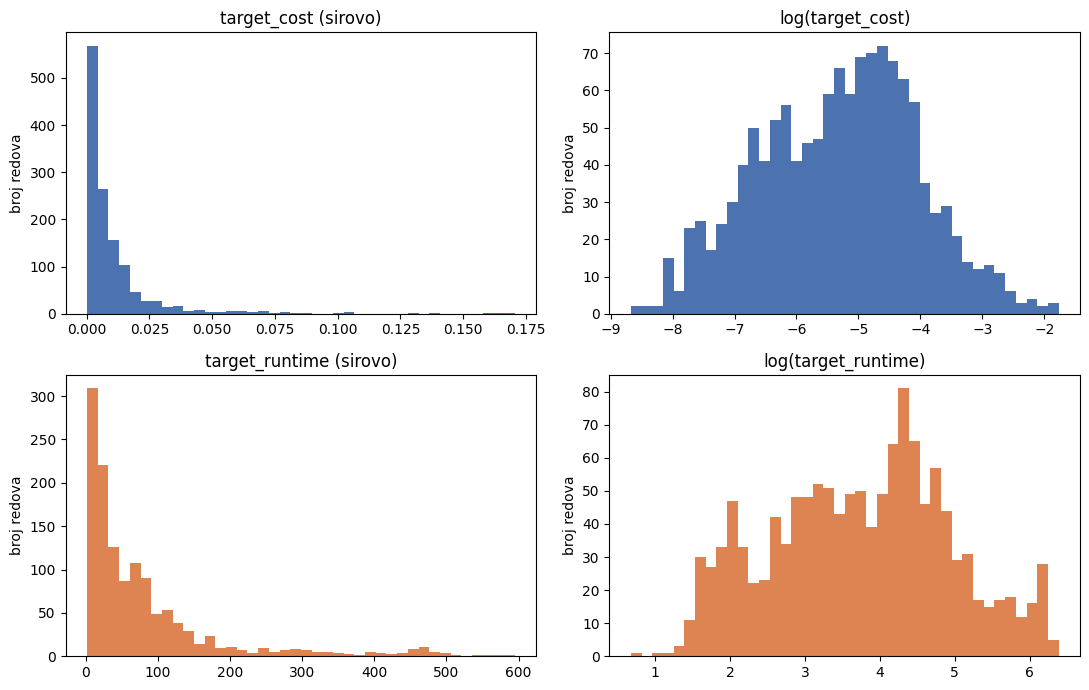

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes[0, 0].hist(df["target_cost"], bins=40, color="#4C72B0")
axes[0, 0].set_title("target_cost (sirovo)")
axes[0, 1].hist(np.log(df["target_cost"]), bins=40, color="#4C72B0")
axes[0, 1].set_title("log(target_cost)")
axes[1, 0].hist(df["target_runtime"], bins=40, color="#DD8452")
axes[1, 0].set_title("target_runtime (sirovo)")
axes[1, 1].hist(np.log(df["target_runtime"]), bins=40, color="#DD8452")
axes[1, 1].set_title("log(target_runtime)")
for ax in axes.flat:
    ax.set_ylabel("broj redova")
plt.tight_layout()
plt.show()

Oba targeta su jako desno-skewed (nekoliko redova sa velikim vrednostima, većina blizu nule).

Bitna napomena: koristimo **`log`**, ne `log1p`. `target_cost` ima vrednosti dosta manje od 1 (0.0002-0.17), a `log1p(x) = ln(1+x) ≈ x` upravo za tako male vrednosti - pa bi `log1p` transformacija na cost-u skoro ništa ne promenila (raspodela bi ostala gotovo identična sirovoj). Pošto su obe mete striktno pozitivne (nema nula), obična `log` transformacija je ispravan izbor - daje pravu kompresiju desno-skewed raspodele i pomaže modelu da lakše konvergira.

### 2.5 Priprema podataka za model

Koraci pripreme:

1. **Split** 70/15/15 (train/val/test), **grupisan** po ključu `(instance_type, nodes, task, dataset)` - dataset sadrži 45 kombinacija (3.6%, ~7% redova) sa po 2 ponovljena merenja (isti config pokrenut dvaput, različit runtime/cost usled šuma pri merenju). Običan nasumičan split bi mogao da stavi jedno merenje u train a njegovog skoro-identičnog blizanca u test, što bi veštački naduvalo test metrike. Grupisan split (`GroupShuffleSplit`) garantuje da svi duplikati istog config-a idu zajedno.
2. **Log-transformacija** targeta: `log(target_cost)`, `log(target_runtime)` - razlog objašnjen u 2.4.
3. **Standardizacija** numeričkih ulaza (`vcpu`, `ram_gb`, `nodes`) - `StandardScaler` fit **samo** na train delu.
4. **One-hot** enkodiranje kategorijskih ulaza (`task`, `dataset`).


In [6]:
# Provera tvrdnje iz teksta iznad: koliko (instance,nodes,task,dataset) kombinacija ima vise od 1 merenja
key_check = df["instance_type"] + "_" + df["nodes"].astype(str) + "_" + df["task"] + "_" + df["dataset"]
counts_check = key_check.value_counts()
n_dup_groups = (counts_check > 1).sum()
n_dup_rows = counts_check[counts_check > 1].sum()
print(f"Ukupno jedinstvenih (instance,nodes,task,dataset) kombinacija: {len(counts_check)}")
print(f"Kombinacija sa ponovljenim merenjem (>1 red): {n_dup_groups} ({n_dup_groups/len(counts_check)*100:.1f}%)")
print(f"Redova obuhvaćenih ponovljenim merenjima: {n_dup_rows} ({n_dup_rows/len(df)*100:.1f}%)")

Ukupno jedinstvenih (instance,nodes,task,dataset) kombinacija: 1237
Kombinacija sa ponovljenim merenjem (>1 red): 45 (3.6%)
Redova obuhvaćenih ponovljenim merenjima: 90 (7.0%)


In [7]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder

group_key = (df["instance_type"] + "_" + df["nodes"].astype(str) + "_" + df["task"] + "_" + df["dataset"])

# 70/15/15: prvo izdvajamo test (15%), pa od preostalih 85% izdvajamo val tako da bude 15% od ukupnog (~17.65% od 85%)
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=RANDOM_SEED)
trainval_idx, test_idx = next(gss_test.split(df, groups=group_key))
df_trainval, df_test = df.iloc[trainval_idx].reset_index(drop=True), df.iloc[test_idx].reset_index(drop=True)

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.1765, random_state=RANDOM_SEED)
group_key_tv = group_key.iloc[trainval_idx].reset_index(drop=True)
train_idx, val_idx = next(gss_val.split(df_trainval, groups=group_key_tv))
df_train, df_val = df_trainval.iloc[train_idx].reset_index(drop=True), df_trainval.iloc[val_idx].reset_index(drop=True)

print(f"train={len(df_train)}  val={len(df_val)}  test={len(df_test)}   (ukupno {len(df_train)+len(df_val)+len(df_test)} / {len(df)})")


def key_set(d):
    return set((d["instance_type"] + "_" + d["nodes"].astype(str) + "_" + d["task"] + "_" + d["dataset"]).tolist())


assert not (key_set(df_train) & key_set(df_val))
assert not (key_set(df_train) & key_set(df_test))
assert not (key_set(df_val) & key_set(df_test))
print("Provera: nema curenja grupa između split-ova. OK.")


train=895  val=194  test=193   (ukupno 1282 / 1282)
Provera: nema curenja grupa između split-ova. OK.


In [8]:
NUM_COLS = ["vcpu", "ram_gb", "nodes"]
CAT_COLS = ["task", "dataset"]

scaler = StandardScaler().fit(df_train[NUM_COLS])
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore").fit(df_train[CAT_COLS])
FEATURE_NAMES = NUM_COLS + list(encoder.get_feature_names_out(CAT_COLS))


def featurize(frame):
    Xn = scaler.transform(frame[NUM_COLS])
    Xc = encoder.transform(frame[CAT_COLS])
    return np.hstack([Xn, Xc]).astype(np.float32)


def make_target(frame, col):
    return np.log(frame[col].values).astype(np.float32).reshape(-1, 1)


X_train, X_val, X_test = featurize(df_train), featurize(df_val), featurize(df_test)
y_train_cost, y_val_cost, y_test_cost = make_target(df_train, "target_cost"), make_target(df_val, "target_cost"), make_target(df_test, "target_cost")
y_train_rt, y_val_rt, y_test_rt = make_target(df_train, "target_runtime"), make_target(df_val, "target_runtime"), make_target(df_test, "target_runtime")

print("Dimenzija ulaznog vektora (input_dim):", X_train.shape[1])
print("Feature redosled:", FEATURE_NAMES)


Dimenzija ulaznog vektora (input_dim): 16
Feature redosled: ['vcpu', 'ram_gb', 'nodes', 'task_kmeans', 'task_linear_regression', 'task_logistic_regression', 'task_naive_bayes', 'task_poisson_regression', 'task_polynomial_features', 'task_quantile_transformer', 'task_spectral_clustering', 'task_standard_scaler', 'task_xgboost', 'dataset_buzz', 'dataset_creditcard', 'dataset_santander']


## 3. Arhitektura modela

Koristimo **dva odvojena** regresiona modela (MLP) - jedan za `target_cost`, jedan za `target_runtime` - umesto jednog multi-output modela. Ovo je namerna odluka: izbegava se potreba za balansiranjem dva gubitka različitih skala/normalizacija u jednoj loss funkciji, i omogućava da se svaki model nezavisno podešava (npr. drugačiji hiperparametri ako se pokaže da je potrebno).

Arhitektura (identična za oba modela, sa odvojenim instancama/skalerima):

```
Linear(input_dim, 64) -> ReLU -> Dropout(0.2) -> Linear(64, 32) -> ReLU -> Linear(32, 1)
```

- `input_dim` = 16 (3 numerička + 10 one-hot za task + 3 one-hot za dataset)
- Dva skrivena sloja (64, 32) su dovoljna kapacitet za ~900 trening redova - veća mreža bi rizikovala overfitting na ovako malom datasetu.
- `Dropout(0.2)` posle prvog skrivenog sloja kao regularizacija.
- Izlazni sloj bez aktivacije (linearan) - regresija na `log(target)`, vrednost može biti bilo koji realan broj.


In [9]:
import torch
import torch.nn as nn

torch.manual_seed(RANDOM_SEED)


class MLPRegressor(nn.Module):
    def __init__(self, input_dim, hidden1=64, hidden2=32, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, 1),
        )

    def forward(self, x):
        return self.net(x)


print(MLPRegressor(X_train.shape[1]))


MLPRegressor(
  (net): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=1, bias=True)
  )
)


## 4. Trening

Funkcija za trening implementira:

- **Adam** optimizator, **MSELoss** na `log`-transformisanom targetu
- mini-batch trening (`DataLoader`, `batch_size=32`)
- **Early stopping**: prati validacioni gubitak, čuva težine najboljeg modela, prekida trening posle `patience=15` epoha bez poboljšanja
- `max_epochs=250` - dovoljno visoko da early stopping praktično uvek prekine trening pre limita


In [10]:
def train_model(X_tr, y_tr, X_va, y_va, hidden1=64, hidden2=32, dropout=0.2,
                 lr=1e-3, batch_size=32, max_epochs=250, patience=15, verbose=True):
    Xt, yt = torch.tensor(X_tr), torch.tensor(y_tr)
    Xv, yv = torch.tensor(X_va), torch.tensor(y_va)

    model = MLPRegressor(X_tr.shape[1], hidden1, hidden2, dropout)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(Xt, yt),
                                          batch_size=batch_size, shuffle=True)

    best_val_loss = float("inf")
    best_state = None
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(max_epochs):
        model.train()
        batch_losses = []
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(Xv), yv).item()

        history["train_loss"].append(float(np.mean(batch_losses)))
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f"Early stopping na epohi {epoch + 1} (najbolji val_loss={best_val_loss:.5f})")
                break
    else:
        if verbose:
            print(f"Dostignut max_epochs={max_epochs} (najbolji val_loss={best_val_loss:.5f})")

    model.load_state_dict(best_state)
    return model, history, best_val_loss


In [11]:
print("Trening modela za COST:")
model_cost, hist_cost, _ = train_model(X_train, y_train_cost, X_val, y_val_cost)

print("\nTrening modela za RUNTIME:")
model_rt, hist_rt, _ = train_model(X_train, y_train_rt, X_val, y_val_rt)


Trening modela za COST:
Early stopping na epohi 122 (najbolji val_loss=0.11194)

Trening modela za RUNTIME:
Early stopping na epohi 114 (najbolji val_loss=0.05868)


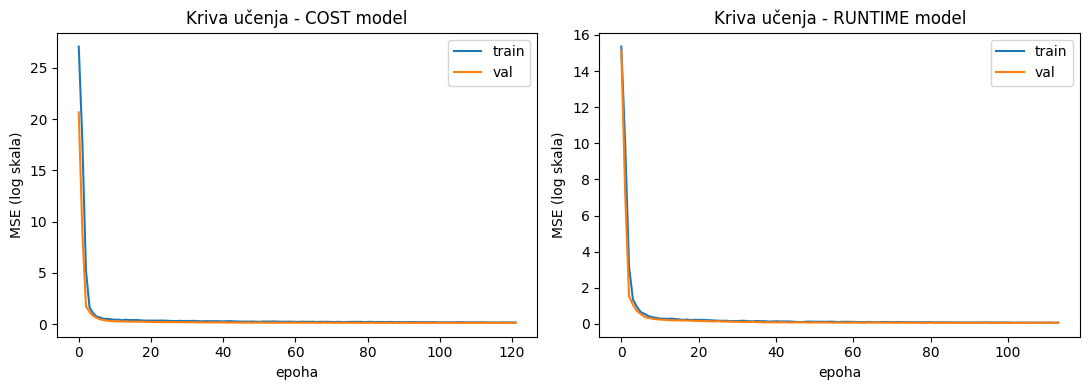

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(hist_cost["train_loss"], label="train")
axes[0].plot(hist_cost["val_loss"], label="val")
axes[0].set_title("Kriva učenja - COST model")
axes[0].set_xlabel("epoha"); axes[0].set_ylabel("MSE (log skala)"); axes[0].legend()

axes[1].plot(hist_rt["train_loss"], label="train")
axes[1].plot(hist_rt["val_loss"], label="val")
axes[1].set_title("Kriva učenja - RUNTIME model")
axes[1].set_xlabel("epoha"); axes[1].set_ylabel("MSE (log skala)"); axes[1].legend()
plt.tight_layout()
plt.show()


## 5. Analiza osetljivosti i hiperparametarska optimizacija

### 5.1 Hiperparametarska pretraga

Isprobavamo manji, ručno biran skup kombinacija (veličine skrivenih slojeva, dropout, learning rate) umesto punog grid pretraživanja - dovoljno da pokažemo uticaj svakog hiperparametra i izaberemo najbolju konfiguraciju po validacionom gubitku, bez nepotrebno velikog broja treninga.

Pretragu radimo na **cost** modelu (primarni cilj projekta je optimizacija troška) i primenjujemo pronađenu najbolju konfiguraciju i na runtime model.


In [13]:
HPARAM_GRID = [
    {"hidden1": 32,  "hidden2": 16, "dropout": 0.1, "lr": 1e-3},
    {"hidden1": 64,  "hidden2": 32, "dropout": 0.1, "lr": 1e-3},
    {"hidden1": 64,  "hidden2": 32, "dropout": 0.2, "lr": 1e-3},
    {"hidden1": 64,  "hidden2": 32, "dropout": 0.3, "lr": 1e-3},
    {"hidden1": 64,  "hidden2": 32, "dropout": 0.2, "lr": 5e-4},
    {"hidden1": 128, "hidden2": 64, "dropout": 0.2, "lr": 1e-3},
    {"hidden1": 128, "hidden2": 64, "dropout": 0.3, "lr": 5e-4},
    {"hidden1": 32,  "hidden2": 16, "dropout": 0.2, "lr": 5e-4},
]

hparam_results = []
for cfg in HPARAM_GRID:
    _, _, best_val = train_model(X_train, y_train_cost, X_val, y_val_cost, max_epochs=250, patience=15, verbose=False, **cfg)
    hparam_results.append({**cfg, "best_val_loss": best_val})

hparam_df = pd.DataFrame(hparam_results).sort_values("best_val_loss").reset_index(drop=True)
hparam_df


,hidden1,hidden2,dropout,lr,best_val_loss
0,64,32,0.1,0.0010,0.095191
1,64,32,0.2,0.0010,0.102614
2,128,64,0.2,0.0010,0.106850
3,64,32,0.2,0.0005,0.111821
4,32,16,0.1,0.0010,0.113284
5,128,64,0.3,0.0005,0.113362
6,32,16,0.2,0.0005,0.122302
7,64,32,0.3,0.0010,0.123144


In [14]:
best_cfg = hparam_df.iloc[0][["hidden1", "hidden2", "dropout", "lr"]].to_dict()
best_cfg["hidden1"], best_cfg["hidden2"] = int(best_cfg["hidden1"]), int(best_cfg["hidden2"])
print("Najbolja konfiguracija:", best_cfg)

print("\nPonovni trening FINALNIH modela sa najboljom konfiguracijom:")
model_cost, hist_cost, _ = train_model(X_train, y_train_cost, X_val, y_val_cost, max_epochs=250, patience=15, **best_cfg)
model_rt, hist_rt, _ = train_model(X_train, y_train_rt, X_val, y_val_rt, max_epochs=250, patience=15, **best_cfg)


Najbolja konfiguracija: {'hidden1': 64, 'hidden2': 32, 'dropout': 0.1, 'lr': 0.001}

Ponovni trening FINALNIH modela sa najboljom konfiguracijom:
Early stopping na epohi 101 (najbolji val_loss=0.11194)
Early stopping na epohi 111 (najbolji val_loss=0.05796)


### 5.2 Analiza osetljivosti na ulazne promenljive

**Važna napomena**: ovde koristimo isključivo `vcpu, ram_gb, nodes, task, dataset` kao ulaze - **ne** i `instance_type` (koji je potpuno određen sa vcpu+ram_gb). 


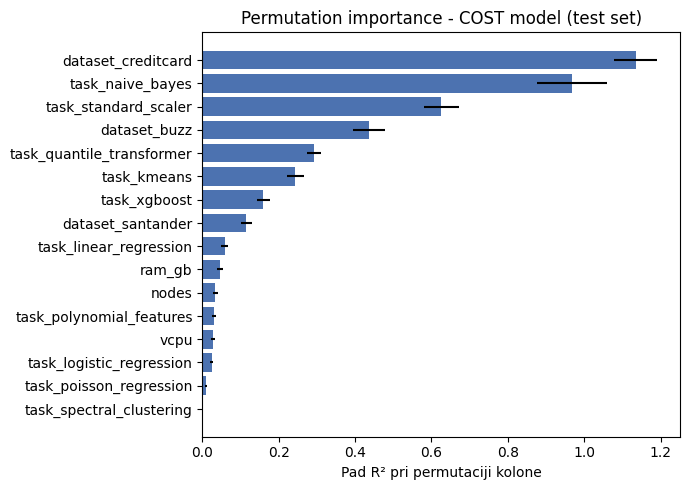

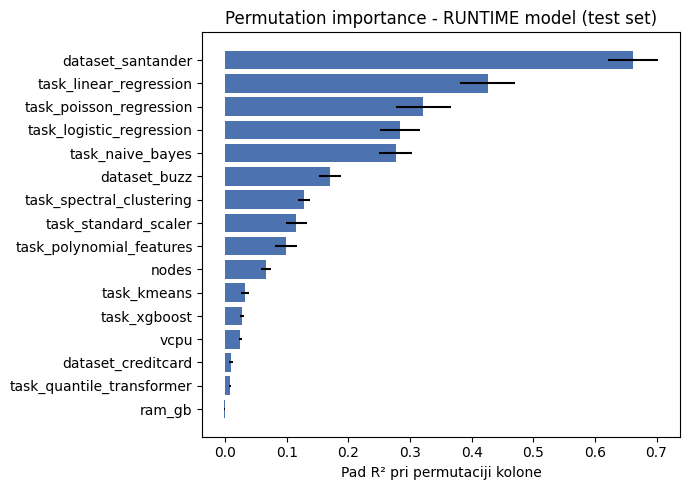

In [15]:
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, RegressorMixin


class TorchRegressorWrapper(BaseEstimator, RegressorMixin):
    # Sklearn-kompatibilan omotac da bismo mogli da koristimo sklearn permutation_importance nad PyTorch modelom.
    def __init__(self, model):
        self.model = model

    def fit(self, X, y):
        return self

    def predict(self, X):
        self.model.eval()
        with torch.no_grad():
            return self.model(torch.tensor(X.astype(np.float32))).numpy().flatten()



def plot_permutation_importance(model, X, y, title):
    wrapper = TorchRegressorWrapper(model)
    result = permutation_importance(wrapper, X, y.flatten(), n_repeats=20, random_state=RANDOM_SEED, scoring="r2")
    imp = pd.DataFrame({"feature": FEATURE_NAMES, "importance": result.importances_mean,
                         "std": result.importances_std}).sort_values("importance", ascending=True)
    plt.figure(figsize=(7, 5))
    plt.barh(imp["feature"], imp["importance"], xerr=imp["std"], color="#4C72B0")
    plt.xlabel("Pad R² pri permutaciji kolone")
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return imp


imp_cost = plot_permutation_importance(model_cost, X_test, y_test_cost, "Permutation importance - COST model (test set)")
imp_rt = plot_permutation_importance(model_rt, X_test, y_test_rt, "Permutation importance - RUNTIME model (test set)")


**Cost model** se najviše oslanja na to *koji je posao u pitanju* - prepoznaje da su `creditcard`, `naive_bayes` i `standard_scaler` po prirodi jeftini poslovi. Hardver (`vcpu`, `ram_gb`, `nodes`) ima znatno manji uticaj - konzistentno sa Diskusijom, gde je objašnjeno da je cost pre svega određen identitetom posla, dok hardver dodaje finiju korekciju.

**Runtime model** se najviše oslanja na `dataset_santander` (najveći dataset) i nekoliko algoritamski zahtevnijih task-ova. Od hardverskih feature-a, `nodes` ima najviše uticaja (više nodova = više paralelizma), dok `vcpu`/`ram_gb` imaju nizak pojedinačni uticaj - delom i zato što su međusobno korelisani (veće instance imaju i više vCPU i više RAM-a), pa gubitak jednog delimično nadoknađuje onaj drugi.

**Zaključak**: kod oba modela, task/dataset nose više informacije nego pojedinačni hardverski parametri - što se poklapa sa ranijim nalazom da je runtime dosta predvidljiviji od cost-a (videti Diskusija).

## 6. Rezultati evaluacije

### 6.1 Tačnost modela na test skupu


In [16]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


def evaluate(model, X, y_log):
    model.eval()
    with torch.no_grad():
        pred_log = model(torch.tensor(X)).numpy().flatten()
    pred = np.exp(pred_log)
    true = np.exp(y_log.flatten())
    return {
        "R2": r2_score(true, pred),
        "MAE": mean_absolute_error(true, pred),
        "RMSE": float(np.sqrt(mean_squared_error(true, pred))),
    }, true, pred


metrics_cost, true_cost, pred_cost = evaluate(model_cost, X_test, y_test_cost)
metrics_rt, true_rt, pred_rt = evaluate(model_rt, X_test, y_test_rt)

print("COST model (test):", metrics_cost)
print("RUNTIME model (test):", metrics_rt)


COST model (test): {'R2': 0.8440569639205933, 'MAE': 0.0027613576967269182, 'RMSE': 0.0063033558269398335}
RUNTIME model (test): {'R2': 0.9301037788391113, 'MAE': 11.128856658935547, 'RMSE': 27.495026849683995}


Runtime model (R²=0.93) je precizniji od cost modela (R²=0.84) - očekivano, jer cost mora implicitno da nauči i runtime i cenu instance zajedno (videti Diskusija).

Za cost model, MAE=0.0028 je blizu tipične vrednosti `target_cost` za jeftinije poslove (raspon je 0.0002-0.17) - greška je time relativno velika baš za te slučajeve, dok je RMSE (0.0063) više nego duplo veći od MAE, što znači da par redova sa velikom greškom vuku prosek na gore (konzistentno sa nalazom iz 5.2 da model ima problema baš sa prepoznavanjem "jeftinih" poslova).

Za runtime model, MAE=11.1s je mala greška u odnosu na ceo opseg (2-600s), ali RMSE=27.5s (više nego duplo veći od MAE) pokazuje isti obrazac - greška raste na dužim poslovima. Deo ove greške je i neizbežan: u 7. Diskusiji je pokazano da ponovljena merenja istog config-a variraju i do 63%, pa nijedan model ne može biti tačniji od šuma koji sam dataset nosi.

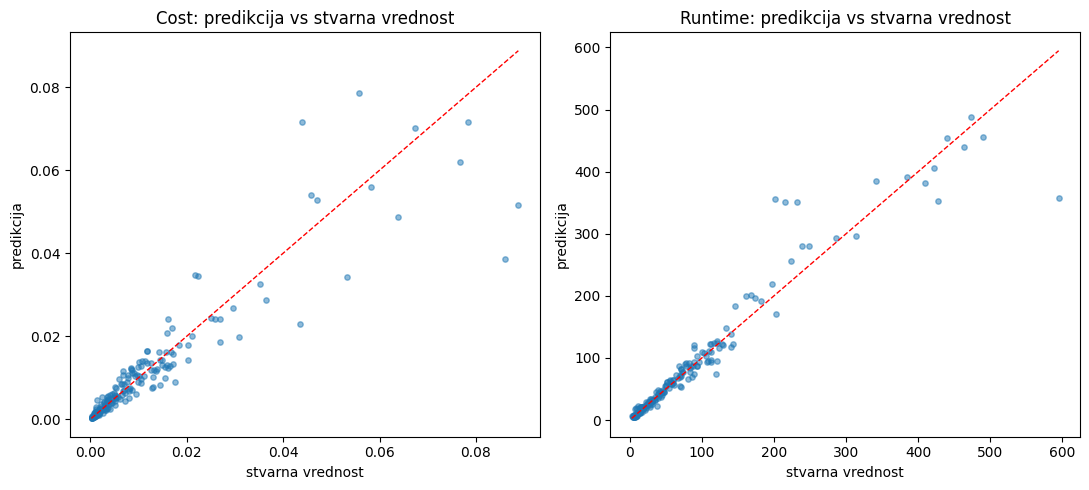

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, true, pred, title in [(axes[0], true_cost, pred_cost, "Cost: predikcija vs stvarna vrednost"),
                                (axes[1], true_rt, pred_rt, "Runtime: predikcija vs stvarna vrednost")]:
    ax.scatter(true, pred, alpha=0.5, s=15)
    lims = [min(true.min(), pred.min()), max(true.max(), pred.max())]
    ax.plot(lims, lims, "r--", linewidth=1)
    ax.set_xlabel("stvarna vrednost"); ax.set_ylabel("predikcija"); ax.set_title(title)
plt.tight_layout()
plt.show()


Za oba modela, tačke se čvrsto drže dijagonale u donjem delu opsega (jeftini/kratki poslovi) - tu je i najviše podataka, pošto su oba targeta desno-skewed. Rasipanje oko dijagonale raste kod skupljih/dužih poslova, u oba smera (i precenjivanje i potcenjivanje) - to su isti retki, "teški" slučajevi koji vuku RMSE znatno iznad MAE (videti tekst iznad).

Kod runtime grafika posebno se izdvaja najduži posao (stvarno ~600s) čija je predikcija znatno niža (~360s) - model ga potcenjuje. Ovakvi ekstremni slučajevi su retki u trening skupu, pa model teži da njihovu predikciju "povuče" bliže tipičnim vrednostima umesto da ekstrapolira do stvarnog ekstrema.

### 6.2 Optimizacija resursa: constraint-based greedy/lokalna pretraga

**Zadatak**: za dati posao (`task`, `dataset`) i zadato ograničenje na vreme izvršavanja (`runtime <= threshold`), pronaći konfiguraciju resursa (instanca + broj nodova) koja **minimizuje predviđeni trošak**.

**Prostor kandidata**: 12 realnih GCP instanci × `nodes ∈ {2,3,4,5}` = **48 kombinacija**, za fiksiran posao.

**Napomena**: na N=48, iscrpno isprobavanje svih kombinacija bi i inače bilo jeftino - vrednost greedy pretrage ovde nije ušteda vremena, nego demonstracija pristupa koji bi se skalirao na realniji, mnogo veći prostor konfiguracija (više provajdera, regiona, tipova instanci), gde iscrpno isprobavanje ne bi bilo izvodljivo.

**Definicija suseda** (za hill climbing): kandidat je par (instanca, nodes). Susedi se dobijaju sa jednim od sledećih koraka:
- `nodes ± 1` (ista instanca)
- promena veličine `2 vCPU <-> 4 vCPU` (ista family/type)
- promena tipa `standard <-> highcpu <-> highmem` (ista family/vcpu)
- promena family `e2 <-> n1` (isti type/vcpu)

**Algoritam** (hill climbing sa 3 nasumična restarta): iz trenutnog kandidata, pogledaj sve susede, pređi na najboljeg (po kriterijumu ispod) ako je bolji od trenutnog, ponavljaj dok nema poboljšanja (lokalni optimum). Ponovi sa 3 različite nasumične početne tačke, uzmi najbolje pronađeno rešenje.

**Kriterijum poređenja kandidata** (feasibility-first): kandidat koji zadovoljava `runtime <= threshold` je uvek bolji od onog koji ne zadovoljava; među izvodljivim kandidatima bira se niži trošak; među neizvodljivim kandidatima bira se niži runtime (korak ka izvodljivosti).

**Neizvodljiv slučaj**: ako baš nijedan od 48 kandidata ne zadovoljava prag, pretraga vraća kandidata sa najmanjim runtime-om koji je pronašla, uz jasno upozorenje da prag nije dostignut.


In [18]:
import random

NODES_RANGE = [2, 3, 4, 5]
TYPE_ORDER = ["highcpu", "standard", "highmem"]

INSTANCE_SPECS = {
    "e2-standard-2": {"family": "e2", "type": "standard", "vcpu": 2, "ram_gb": 8.0},
    "e2-standard-4": {"family": "e2", "type": "standard", "vcpu": 4, "ram_gb": 16.0},
    "e2-highcpu-2":  {"family": "e2", "type": "highcpu",  "vcpu": 2, "ram_gb": 2.0},
    "e2-highcpu-4":  {"family": "e2", "type": "highcpu",  "vcpu": 4, "ram_gb": 4.0},
    "e2-highmem-2":  {"family": "e2", "type": "highmem",  "vcpu": 2, "ram_gb": 16.0},
    "e2-highmem-4":  {"family": "e2", "type": "highmem",  "vcpu": 4, "ram_gb": 32.0},
    "n1-standard-2": {"family": "n1", "type": "standard", "vcpu": 2, "ram_gb": 7.5},
    "n1-standard-4": {"family": "n1", "type": "standard", "vcpu": 4, "ram_gb": 15.0},
    "n1-highcpu-2":  {"family": "n1", "type": "highcpu",  "vcpu": 2, "ram_gb": 1.8},
    "n1-highcpu-4":  {"family": "n1", "type": "highcpu",  "vcpu": 4, "ram_gb": 3.6},
    "n1-highmem-2":  {"family": "n1", "type": "highmem",  "vcpu": 2, "ram_gb": 13.0},
    "n1-highmem-4":  {"family": "n1", "type": "highmem",  "vcpu": 4, "ram_gb": 26.0},
}
ALL_CANDIDATES = [(inst, n) for inst in INSTANCE_SPECS for n in NODES_RANGE]
assert len(ALL_CANDIDATES) == 48


def hardware_neighbors(candidate):
    inst, nodes = candidate
    spec = INSTANCE_SPECS[inst]
    neighbors = []
    if nodes > NODES_RANGE[0]:
        neighbors.append((inst, nodes - 1))
    if nodes < NODES_RANGE[-1]:
        neighbors.append((inst, nodes + 1))

    other_vcpu = 4 if spec["vcpu"] == 2 else 2
    for name, s in INSTANCE_SPECS.items():
        if s["family"] == spec["family"] and s["type"] == spec["type"] and s["vcpu"] == other_vcpu:
            neighbors.append((name, nodes))

    type_idx = TYPE_ORDER.index(spec["type"])
    for delta in (-1, 1):
        j = type_idx + delta
        if 0 <= j < len(TYPE_ORDER):
            for name, s in INSTANCE_SPECS.items():
                if s["family"] == spec["family"] and s["type"] == TYPE_ORDER[j] and s["vcpu"] == spec["vcpu"]:
                    neighbors.append((name, nodes))

    other_family = "n1" if spec["family"] == "e2" else "e2"
    for name, s in INSTANCE_SPECS.items():
        if s["family"] == other_family and s["type"] == spec["type"] and s["vcpu"] == spec["vcpu"]:
            neighbors.append((name, nodes))

    return neighbors


In [19]:
def predict_candidate(task, dataset, candidate):
    inst, nodes = candidate
    spec = INSTANCE_SPECS[inst]
    row = pd.DataFrame([{"vcpu": spec["vcpu"], "ram_gb": spec["ram_gb"], "nodes": nodes,
                          "task": task, "dataset": dataset}])
    x = torch.tensor(featurize(row))
    with torch.no_grad():
        cost = float(np.exp(model_cost(x).numpy().flatten()[0]))
        runtime = float(np.exp(model_rt(x).numpy().flatten()[0]))
    return cost, runtime


def score_key(entry, threshold):
    # Feasibility-first poredjenje: (feasible? 0:1, sekundarni kriterijum).
    if entry["runtime"] <= threshold:
        return (0, entry["cost"])
    return (1, entry["runtime"])


def evaluate_candidate(cache, task, dataset, candidate):
    if candidate not in cache:
        cost, runtime = predict_candidate(task, dataset, candidate)
        cache[candidate] = {"candidate": candidate, "cost": cost, "runtime": runtime}
    return cache[candidate]


def greedy_search(task, dataset, threshold, n_restarts=3, seed=0):
    rng = random.Random(seed)
    cache = {}
    best_overall = None
    for _ in range(n_restarts):
        current = evaluate_candidate(cache, task, dataset, rng.choice(ALL_CANDIDATES))
        improved = True
        while improved:
            improved = False
            best_neighbor = current
            for nb in hardware_neighbors(current["candidate"]):
                nb_entry = evaluate_candidate(cache, task, dataset, nb)
                if score_key(nb_entry, threshold) < score_key(best_neighbor, threshold):
                    best_neighbor = nb_entry
            if best_neighbor["candidate"] != current["candidate"]:
                current = best_neighbor
                improved = True
        if best_overall is None or score_key(current, threshold) < score_key(best_overall, threshold):
            best_overall = current
    return best_overall, cache

Pokrenimo greedy pretragu na nekoliko primera poslova i pragova, i pogledajmo koju konfiguraciju predlaže i sa koliko poziva modela.

In [20]:
SCENARIOS = [
    {"task": "kmeans", "dataset": "santander", "threshold": 90.0},
    {"task": "logistic_regression", "dataset": "buzz", "threshold": 150.0},
    {"task": "xgboost", "dataset": "creditcard", "threshold": 30.0},
    {"task": "naive_bayes", "dataset": "santander", "threshold": 20.0},
]

results_rows = []
for sc in SCENARIOS:
    task, dataset, threshold = sc["task"], sc["dataset"], sc["threshold"]
    best, cache = greedy_search(task, dataset, threshold, n_restarts=3, seed=RANDOM_SEED)
    results_rows.append({
        "workload": f"{task}/{dataset}", "threshold_s": threshold,
        "instance": best["candidate"][0], "nodes": best["candidate"][1],
        "pred_cost": round(best["cost"], 5), "pred_runtime": round(best["runtime"], 2),
        "feasible": best["runtime"] <= threshold, "model_calls": len(cache),
    })

results_df = pd.DataFrame(results_rows)
results_df

,workload,threshold_s,instance,nodes,pred_cost,pred_runtime,feasible,model_calls
0,kmeans/santander,90.0,n1-highcpu-4,4,0.01472,88.62,True,35
1,logistic_regression/buzz,150.0,n1-highcpu-4,5,0.02192,133.37,True,35
2,xgboost/creditcard,30.0,n1-highcpu-2,3,0.00151,24.54,True,30
3,naive_bayes/santander,20.0,n1-standard-2,2,0.00106,19.14,True,33


Vidimo da greedy pretraga u svakom primeru koristi znatno manje od 48 poziva modela, uz konfiguraciju koja zadovoljava zadati prag uz nizak trošak.

Testirajmo i eksplicitno neizvodljiv slučaj (nerealno nizak prag):

In [21]:
task, dataset, threshold = "logistic_regression", "santander", 1.0  # nerealno nizak prag

g_best, g_cache = greedy_search(task, dataset, threshold, n_restarts=3, seed=RANDOM_SEED)

print(f"Workload={task}/{dataset}, prag runtime <= {threshold}s")
print(f"Greedy: {g_best['candidate']}  cost={g_best['cost']:.5f}  runtime={g_best['runtime']:.2f}  feasible={g_best['runtime'] <= threshold}")
if g_best["runtime"] > threshold:
    print()
    print(f"UPOZORENJE: nijedna razmatrana konfiguracija ne zadovoljava runtime <= {threshold}s. "
          f"Vraćena je najbrža pronađena opcija.")

Workload=logistic_regression/santander, prag runtime <= 1.0s
Greedy: ('n1-highmem-4', 5)  cost=0.03109  runtime=96.77  feasible=False

UPOZORENJE: nijedna razmatrana konfiguracija ne zadovoljava runtime <= 1.0s. Vraćena je najbrža pronađena opcija.


## 7. Diskusija

**Cost je teže predvideti nego runtime.** Pošto je `cost = runtime × cena_po_satu(instance) × nodes`, cost model mora implicitno da nauči dva efekta odjednom - koliko dugo posao traje na datom hardveru, i koliko taj hardver košta po satu (nelinearna, stepenasta funkcija tipa instance) - dok runtime model uči samo prvi efekat. Zato je u rezultatima iz 6.1 očekivano da model za runtime ostvari viši R² na test skupu od modela za cost.

Ovo otvara pitanje da li je poseban cost model uopšte neophodan. Pošto je u ovom datasetu cena konstruisana upravo kao `runtime × poznata_cena_po_satu`, teorijski najprecizniji pristup bio bi da se trenira samo model za runtime, a cost izračuna analitički (`runtime_pred × cena_instance × nodes`) - bez ikakve dodatne greške na strani cost-a. Ipak, zadržavamo i eksplicitan cost model, jer u realnom cloud okruženju cena retko zavisi isključivo od runtime-a i cene po satu - tu su i troškovi prenosa podataka, popusti na rezervisane/spot instance, troškovi skladištenja i slično, koje analitička formula ne bi obuhvatila. Eksplicitan cost model je time na *ovom* datasetu manje precizan od pukog analitičkog izračuna (jer uvodi nepotrebnu dodatnu grešku modela), ali predstavlja opštiji pristup koji bi se bolje preneo na realističniji scenario u kom cena nije čista funkcija runtime-a.

**Ograničenja pristupa**:
- Dataset je ograničen na jedan cloud provajder (GCP) i 30 specifičnih (task, dataset) kombinacija - model se ne generalizuje na potpuno nove tipove poslova van ovog skupa.
- Na prostoru od 48 kandidata iscrpna pretraga bi i inače bila jeftina, i ne poredimo je eksplicitno sa greedy rešenjem (6.2) - ne možemo izmeriti koliko je pronađeno rešenje blizu pravog optimuma; oslanjamo se na hardverski smislen dizajn suseda i 3 nasumična restarta kao heurističku garanciju kvaliteta. Prava vrednost greedy pristupa bi se pokazala na mnogo većem prostoru (više provajdera/regiona/tipova instanci), gde iscrpna pretraga ne bi bila izvodljiva.
- 45 od 1237 (instance, nodes, task, dataset) kombinacija u datasetu su pokrenute dvaput - potpuno ista konfiguracija, ista mašina, isti posao. Runtime tih ponovljenih merenja se ipak razlikuje u proseku ~9% (medijalno ~6%), a u najgorem slučaju i do 63% (npr. `n1-highmem-2`, 5 nodova, `xgboost`/`santander`: 142.9s naspram 74.4s) - verovatno usled deljene cloud infrastrukture u trenutku merenja. Ovo postavlja gornju granicu tačnosti bilo kog modela: čak i savršen model ne može tačno da predvidi pojedinačno merenje kad sam podatak nosi ovoliki šum.
- Hiperparametarska pretraga je namerno ograničena na manji, ručno biran skup kombinacija, a ne iscrpna/automatizovana pretraga (npr. Optuna) - dovoljno za demonstraciju uticaja hiperparametara u okviru ovog projekta.

In [22]:
# Provera tvrdnje iz teksta ispod: koliko se runtime razlikuje izmedju 2 merenja iste (instance,nodes,task,dataset) konfiguracije
key = df["instance_type"] + "_" + df["nodes"].astype(str) + "_" + df["task"] + "_" + df["dataset"]
counts = key.value_counts()
dup_keys = counts[counts > 1].index

rt_spread = (df[key.isin(dup_keys)]
             .groupby(key)["target_runtime"]
             .apply(lambda s: (s.max() - s.min()) / s.mean() * 100))
print(f"Kombinacija sa ponovljenim merenjem: {len(dup_keys)} / {len(counts)}")
print(rt_spread.describe())

worst_key = rt_spread.idxmax()
print()
print("Najveca relativna razlika kod konfiguracije:", worst_key)
df[key == worst_key][["instance_type", "nodes", "task", "dataset", "target_runtime", "target_cost"]]

Kombinacija sa ponovljenim merenjem: 45 / 1237
count    45.000000
mean      8.888291
std      10.937525
min       0.036899
25%       3.508152
50%       6.344537
75%      10.403711
max      63.111332
Name: target_runtime, dtype: float64

Najveca relativna razlika kod konfiguracije: n1-highmem-2_5_xgboost_santander


,instance_type,nodes,task,dataset,target_runtime,target_cost
333,n1-highmem-2,5,xgboost,santander,142.926578,0.025866
1255,n1-highmem-2,5,xgboost,santander,74.360267,0.013457


## 8. Zaključak

Projekat pokazuje da se, na osnovu istorijskih merenja izvršavanja radnih opterećenja na različitim hardverskim konfiguracijama, neuronska mreža može naučiti da predvidi i trošak i vreme izvršavanja sa zadovoljavajućom tačnošću (R² test skupa dat u sekciji 6.1), pod uslovom da se pažljivo reši nekoliko praktičnih problema: dekodiranje anonimizovanog dataseta, izbor konzistentnog podskupa provajdera bez unakrsne kolizije cena, transformacija jako skewed targeta, i izbegavanje redundantnih/curećih feature-a.

Istrenirani modeli su zatim iskorišćeni kao "orakl" unutar constraint-based greedy/lokalne pretrage, koja za dati posao i ograničenje na vreme izvršavanja pronalazi jeftinu konfiguraciju resursa uz znatno manje poziva modela nego što bi zahtevalo iscrpno isprobavanje svih 48 kombinacija. Iako je na ovom (namerno malom, 48-kandidatnom) prostoru brute-force već jeftin, pristup je dizajniran da se skalira na realnije, mnogo veće prostore konfiguracija (više provajdera, regiona i tipova instanci), gde bi iscrpna pretraga bila neizvodljiva - upravo je za takve scenarije greedy pretraga korisna alatka za optimizaciju cloud troškova.
